In [5]:
import sys
from pathlib import Path

# Add parent directory to path so src module can be imported
sys.path.insert(0, str(Path.cwd().parent))

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [7]:
df = pd.read_parquet("../data/marts/fact_returns.parquet")
df.head()

,date,Close,High,Low,Open,Volume,price,returns,vol_30,ma_50,ma_200,ticker
199,2015-10-16,24.906061,25.121387,24.791669,25.072041,156930400,24.906061,-0.007357,0.227629,25.199347,27.060058,AAPL
200,2015-10-19,25.060818,25.065303,24.697454,24.852220,119036800,25.060818,0.006194,0.226150,25.182346,27.064287,AAPL
201,2015-10-20,25.518391,25.608110,24.856712,24.973346,195871200,25.518391,0.018094,0.218037,25.155654,27.074215,AAPL
202,2015-10-21,25.516150,25.924372,25.502690,25.569981,167180800,25.516150,-0.000088,0.209786,25.156865,27.084122,AAPL
203,2015-10-22,25.906424,25.906424,25.592406,25.643995,166616400,25.906424,0.015179,0.204984,25.158032,27.094329,AAPL


In [8]:
from src.quant.risk_metrics import compute_metrics
compute_metrics()

,ticker,sharpe,max_drawdown
0,AAPL,0.709027,-0.401615
1,MSFT,0.750739,-0.406101
2,GOOGL,0.689303,-0.479546
3,^GSPC,0.549445,-0.361026


In [9]:
from src.quant.portfolio_optimization import optimize_portfolio
weights, _, _ = optimize_portfolio()
weights

array([3.46944695e-18, 9.02056208e-17, 1.70404195e-17, 1.00000000e+00])

In [ ]:
weights, mean_returns, cov = optimize_portfolio()

tickers = ["AAPL", "MSFT", "GOOGL", "^GSPC"]

plt.figure()
plt.bar(tickers, weights)
plt.title("Optimized Portfolio Allocation")
plt.xlabel("Assets")
plt.ylabel("Weight")
plt.show()

**Insight:**  
The optimizer allocates capital based on risk-adjusted returns and inter-asset correlations.  
Assets with lower volatility and favorable covariance receive higher weights, reflecting diversification benefits.

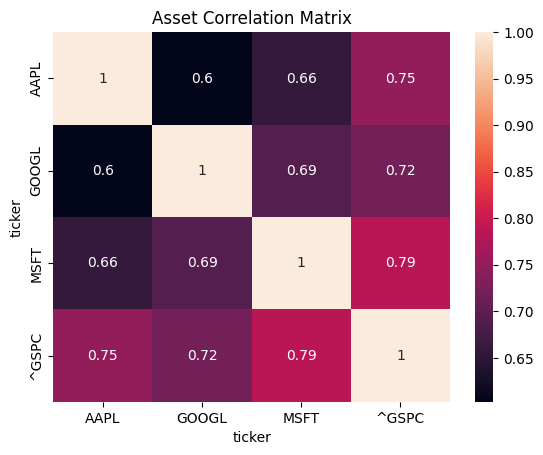

In [12]:
returns_df = pd.read_parquet("../data/marts/fact_returns.parquet")

pivot = returns_df.pivot(index="date", columns="ticker", values="returns")

plt.figure()
sns.heatmap(pivot.corr(), annot=True)
plt.title("Asset Correlation Matrix")
plt.show()